<a href="https://colab.research.google.com/github/MDMynulHasan/Skin-Lesion-Severity-Classifier/blob/main/Skin_Lesion_Severity_Classifier_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_20673/4136467858.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.

First 5 records with new binary labels:


,image_id,dx,target,label
0,ISIC_0027419,bkl,0,Benign
1,ISIC_0025030,bkl,0,Benign
2,ISIC_0026769,bkl,0,Benign
3,ISIC_0025661,bkl,0,Benign
4,ISIC_0031633,bkl,0,Benign


/tmp/ipykernel_20673/4136467858.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])


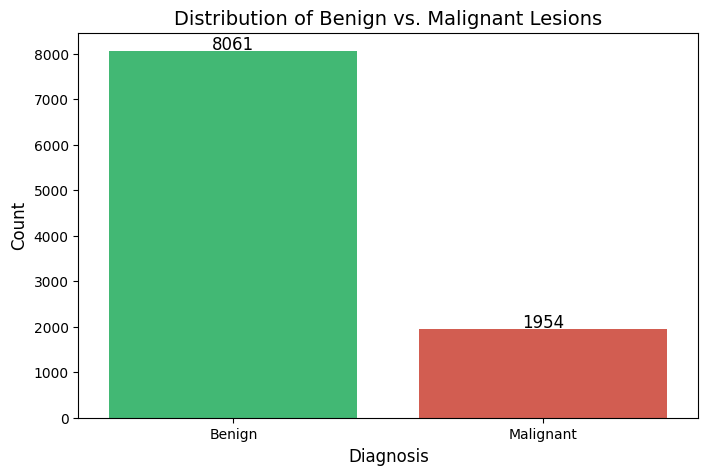

In [3]:
# Install dependencies if you haven't already:
!pip install kagglehub[pandas-datasets] matplotlib seaborn

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fetch the metadata CSV directly into Pandas
file_path = "HAM10000_metadata.csv"

print("Downloading and loading dataset...")
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "kmader/skin-cancer-mnist-ham10000",
  file_path
)

# 2. Map the 7 diagnostic classes to Binary (Benign vs. Malignant)
# Malignant: Melanoma (mel), Basal cell carcinoma (bcc), Actinic keratoses (akiec)
# Benign: Melanocytic nevi (nv), Benign keratosis-like (bkl), Dermatofibroma (df), Vascular (vasc)
malignant_classes = ['mel', 'bcc', 'akiec']

# Create a new column 'target' where 1 = Malignant, 0 = Benign
df['target'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)
df['label'] = df['target'].apply(lambda x: 'Malignant' if x == 1 else 'Benign')

print("\nFirst 5 records with new binary labels:")
display(df[['image_id', 'dx', 'target', 'label']].head())

# 3. Visualize the Class Distribution (Checking for Imbalance)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Benign vs. Malignant Lesions', fontsize=14)
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=12)

plt.show()

1. INSTALL & IMPORTS

In [4]:

!pip install -q kagglehub gradio

import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import kagglehub, cv2, gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

print("TF version:", tf.__version__)


TF version: 2.20.0


2. DOWNLOAD DATASET & LOAD METADATA

In [5]:

print("\n[1] Downloading HAM10000 via kagglehub...")
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset folder:", dataset_path)

# Load metadata CSV
csv_path = os.path.join(dataset_path, "HAM10000_metadata.csv")
df = pd.read_csv(csv_path)

# Map 7 classes -> Binary (Benign=0, Malignant=1)
malignant = ['mel', 'bcc', 'akiec']
df['target'] = df['dx'].apply(lambda x: 1 if x in malignant else 0)
df['label'] = df['target'].map({0: 'Benign', 1: 'Malignant'})

# Locate actual image paths (handles both part_1 / part_2 subfolders)
img_list = glob.glob(os.path.join(dataset_path, "**/*.jpg"), recursive=True)
img_map = {os.path.splitext(os.path.basename(p))[0]: p for p in img_list}
df['path'] = df['image_id'].map(img_map)

# Drop rows where image file is missing
df = df.dropna(subset=['path']).reset_index(drop=True)
print(f"Images found: {len(df)} | Benign: {sum(df.target==0)} | Malignant: {sum(df.target==1)}")


[1] Downloading HAM10000 via kagglehub...
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset folder: /kaggle/input/skin-cancer-mnist-ham10000
Images found: 10015 | Benign: 8061 | Malignant: 1954


3. EDA (Brief but complete)

/tmp/ipykernel_20673/4272675606.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])


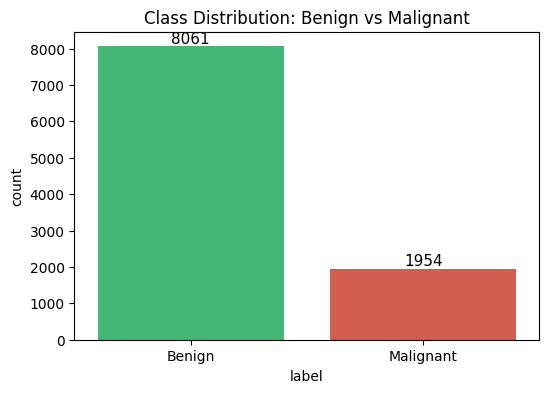

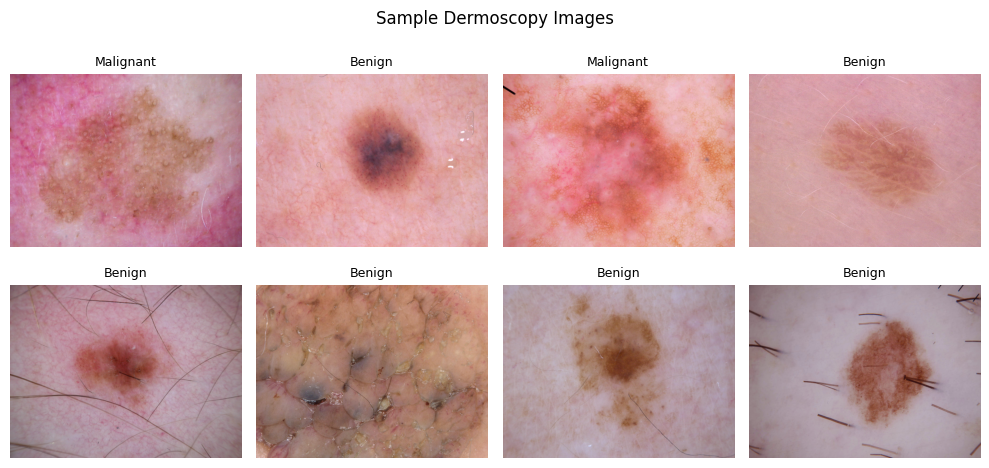

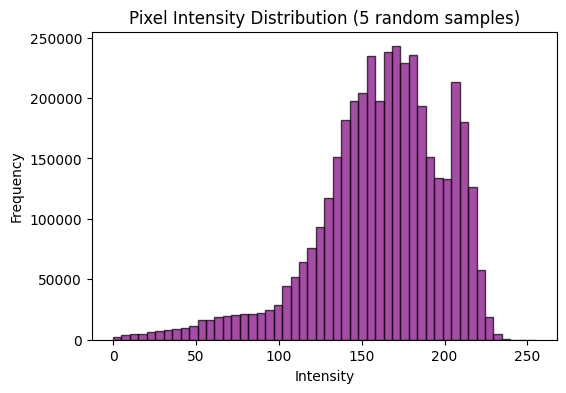

In [6]:

# 3a. Class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution: Benign vs Malignant')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()

# 3b. Show 8 random samples
plt.figure(figsize=(10, 5))
samples = df.sample(8, random_state=42).reset_index(drop=True)
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = plt.imread(samples.loc[i, 'path'])
    plt.imshow(img)
    plt.title(samples.loc[i, 'label'], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Dermoscopy Images')
plt.tight_layout()
plt.show()

# 3c. Pixel intensity distribution (5 random images)
rand_paths = df.sample(5, random_state=7)['path'].values
pixel_vals = np.concatenate([cv2.imread(p).ravel() for p in rand_paths])
plt.figure(figsize=(6, 4))
plt.hist(pixel_vals, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.title('Pixel Intensity Distribution (5 random samples)')
plt.xlabel('Intensity'); plt.ylabel('Frequency')
plt.show()


4. TRAIN / VAL / TEST SPLIT (Stratified)

In [7]:

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['target'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['target'], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 7010 | Val: 1502 | Test: 1503


5. DATA GENERATORS (Resize 224x224, Normalize, Augment)

In [8]:

IMG_SIZE = 224
BATCH = 32

# Training: augmentation + rescale to [0,1]
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='binary', shuffle=True
)

# Validation & Test: rescale only
val_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='binary', shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    class_mode='binary', shuffle=False
)

# Compute balanced class weights for imbalanced data
cw = compute_class_weight('balanced', classes=np.unique(train_df['target']), y=train_df['target'])
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)


Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Class weights: {0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


6. MODEL A: CUSTOM CNN (>=3 Conv layers per brief)

In [9]:

custom_cnn = models.Sequential(name="Custom_CNN", layers=[
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

custom_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("\n[2] Training Custom CNN...")
hist_cnn = custom_cnn.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=class_weights)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[2] Training Custom CNN...
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 164s 671ms/step - accuracy: 0.4221 - auc: 0.5550 - loss: 0.7224 - val_accuracy: 0.1951 - val_auc: 0.5166 - val_loss: 0.7076
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 137s 625ms/step - accuracy: 0.2178 - auc: 0.5115 - loss: 0.6965 - val_accuracy: 0.1991 - val_auc: 0.5119 - val_loss: 0.6941
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 138s 627ms/step - accuracy: 0.3639 - auc: 0.5259 - loss: 0.6924 - val_accuracy: 0.6638 - val_auc: 0.6063 - val_loss: 0.6934
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 137s 621ms/step - accuracy: 0.5501 - auc: 0.5171 - loss: 0.6926 - val_accuracy: 0.7716 - val_auc: 0.5429 - val_loss: 0.6973
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 140s 638ms/step - accuracy: 0.5389 - auc: 0.5048 - loss: 0.6950 - val_accuracy: 0.7983 - val_auc: 0.5129 - val_loss: 0.6926
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 139s 633ms/step - accuracy: 0.5324 - auc: 0.5013 - loss: 0.6930 - val_accuracy: 0.7963 - val_auc: 0.5104 - val_l

7. MODEL B: TRANSFER LEARNING (MobileNetV2, frozen base)

In [10]:

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False  # freeze pretrained base

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(1, activation='sigmoid')(x)

mobilenet = models.Model(inputs=base.input, outputs=out, name="MobileNetV2_TL")
mobilenet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("\n[3] Training MobileNetV2 (Transfer Learning)...")
hist_mob = mobilenet.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=class_weights)



[3] Training MobileNetV2 (Transfer Learning)...
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 185s 756ms/step - accuracy: 0.5715 - auc: 0.4862 - loss: 0.9349 - val_accuracy: 0.5047 - val_auc: 0.5393 - val_loss: 0.7488
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 134s 610ms/step - accuracy: 0.5595 - auc: 0.5703 - loss: 0.7884 - val_accuracy: 0.6198 - val_auc: 0.6747 - val_loss: 0.6667
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 137s 623ms/step - accuracy: 0.5980 - auc: 0.6298 - loss: 0.7249 - val_accuracy: 0.6818 - val_auc: 0.7499 - val_loss: 0.6069
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 137s 623ms/step - accuracy: 0.6385 - auc: 0.6821 - loss: 0.6740 - val_accuracy: 0.7250 - val_auc: 0.7836 - val_loss: 0.5543
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 136s 621ms/step - accuracy: 0.6565 - auc: 0.7075 - loss: 0.6488 - val_accuracy: 0.7330 - val_auc: 0.8002 - val_loss: 0.5517
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 133s 603ms/step - accuracy: 0.6792 - auc: 0.7404 - loss: 0.6135 - val_accuracy: 0.7250 - va

8. EVALUATION FUNCTION (Confusion Matrix, ROC, Report, Curves)

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step

=== Custom CNN RESULTS ===
              precision    recall  f1-score   support

      Benign      0.811     0.973     0.884      1210
   Malignant      0.353     0.061     0.105       293

    accuracy                          0.795      1503
   macro avg      0.582     0.517     0.494      1503
weighted avg      0.721     0.795     0.732      1503



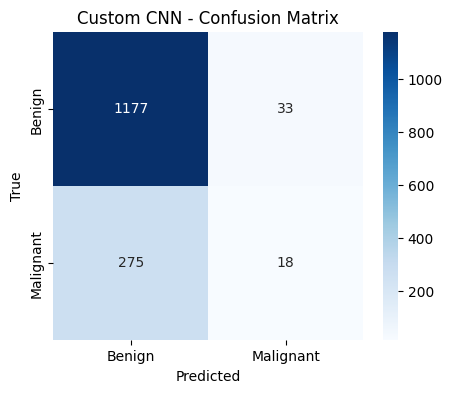

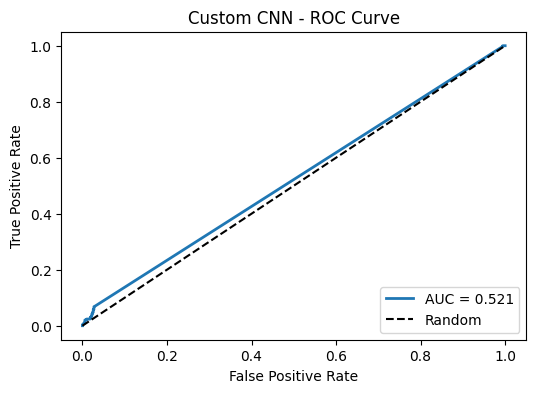

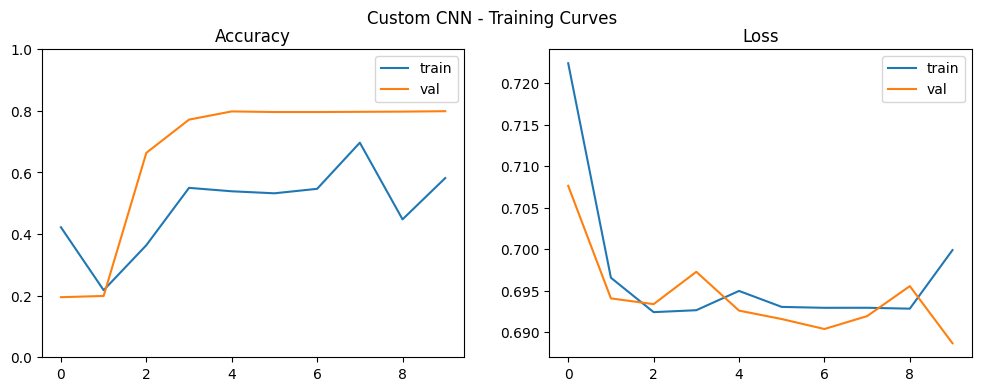

47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 510ms/step

=== MobileNetV2 RESULTS ===
              precision    recall  f1-score   support

      Benign      0.921     0.743     0.823      1210
   Malignant      0.410     0.737     0.527       293

    accuracy                          0.742      1503
   macro avg      0.665     0.740     0.675      1503
weighted avg      0.821     0.742     0.765      1503



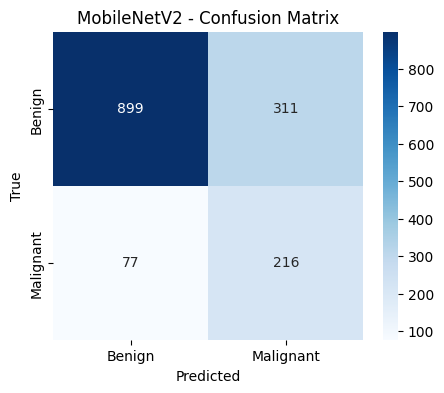

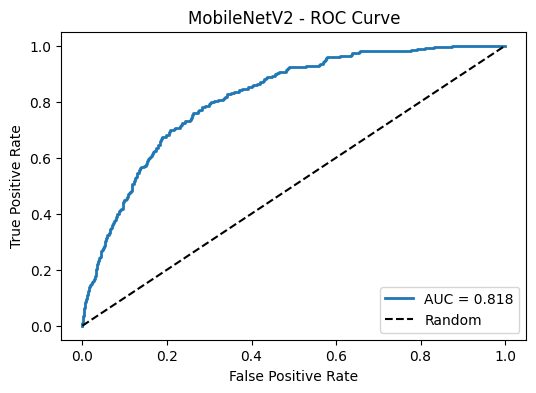

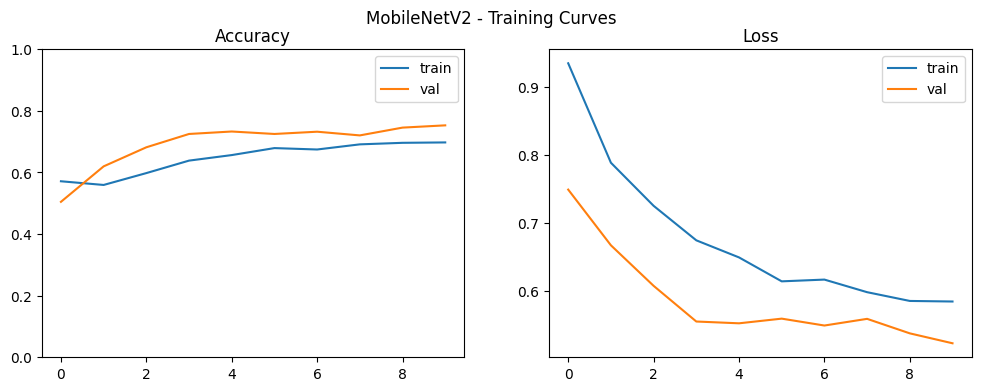

In [11]:

def evaluate(model, test_generator, history, model_name):
    # Predict probabilities
    probs = model.predict(test_generator, steps=len(test_generator))
    y_pred = (probs > 0.5).astype(int).reshape(-1)
    y_true = test_generator.classes  # true labels in generator order

    # Print metrics
    print(f"\n=== {model_name} RESULTS ===")
    print(classification_report(y_true, y_pred, target_names=['Benign','Malignant'], digits=3))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.show()

    # ROC Curve + AUC
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1], [0,1], 'k--', label='Random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Training curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['accuracy'], label='train')
    ax[0].plot(history.history['val_accuracy'], label='val')
    ax[0].set_title('Accuracy'); ax[0].legend(); ax[0].set_ylim(0,1)
    ax[1].plot(history.history['loss'], label='train')
    ax[1].plot(history.history['val_loss'], label='val')
    ax[1].set_title('Loss'); ax[1].legend()
    fig.suptitle(f'{model_name} - Training Curves')
    plt.show()

# Run evaluation on both models
evaluate(custom_cnn, test_gen, hist_cnn, "Custom CNN")
evaluate(mobilenet, test_gen, hist_mob, "MobileNetV2")


9. SAVE BEST MODEL (MobileNetV2 per project tips)

In [12]:

save_path = "best_skin_model.keras"  # native Keras format (recommended)
mobilenet.save(save_path)
print(f"\n[4] Best model saved to: {save_path}")


[4] Best model saved to: best_skin_model.keras


10. GUI (Gradio - runs natively inside Colab)

In [13]:

def classify_lesion(image):
    # image is numpy array (H, W, 3) from Gradio
    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0          # normalize to [0,1]
    img = np.expand_dims(img, axis=0)            # add batch dim

    prob = float(mobilenet.predict(img, verbose=0)[0][0])
    pred_label = "Malignant" if prob > 0.5 else "Benign"
    confidence = prob if pred_label == "Malignant" else (1 - prob)

    # Recommendation text
    if pred_label == "Malignant":
        advice = "⚠️ High risk detected. Please consult a dermatologist as soon as possible."
    else:
        advice = "✅ Low risk appearance. Continue routine self-checks and annual screenings."

    # Markdown output
    result_md = (
        f"### Prediction: **{pred_label}**\n\n"
        f"**Confidence:** {confidence*100:.1f}%\n\n"
        f"**Recommendation:** {advice}\n\n"
        f"---\n"
        f"🩺 **Disclaimer:** This tool is **NOT** a diagnostic device. "
        f"It is intended for educational triage only. Always seek professional medical advice."
    )
    return result_md, confidence

gui = gr.Interface(
    fn=classify_lesion,
    inputs=gr.Image(type="numpy", label="Upload Dermoscopy Image (JPEG/PNG)"),
    outputs=[
        gr.Markdown(label="Classification Result"),
        gr.Slider(0, 1, label="Confidence Score", interactive=False)
    ],
    title="Skin Lesion Severity Classifier",
    description="Upload a skin lesion photo to get a benign vs. malignant risk assessment with a confidence score.",
    flagging_mode="never"
)

print("\n[5] Launching GUI...")
gui.launch(share=True, debug=True)


[5] Launching GUI...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://151d5562af3d790254.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://151d5562af3d790254.gradio.live
